In [28]:
"""
==============================================================================
  ThirdEye Labs — "The Mathematics of Intelligence"
  LAB 0.1 — What Is a Function, Really? (Hands-On in Python)
==============================================================================
Pairs with concept episode S0.1. We turn the "function = machine" idea into
real, runnable code: define functions, plot their graphs, tune a parameter and
watch the curve move, compose two functions, then build a tiny "trainable"
function that fits real data by turning its dials.

WHY THIS LAB: every model in this series is a function. If you can write one,
plot it, and tune it in Python, you already understand the skeleton of machine
learning.

------------------------------------------------------------------------------
SETUP
    pip install numpy matplotlib scikit-learn
Run top-to-bottom:
    python lab_0_1_functions.py
Or paste each numbered SECTION into its own Jupyter cell.
------------------------------------------------------------------------------
"""

import numpy as np
import matplotlib.pyplot as plt

# Deterministic: viewers get exactly what the video shows.
np.random.seed(7)

# House style so the plots match the channel's dark look.
plt.rcParams.update({
    "figure.facecolor": "#0b0e14",
    "axes.facecolor":   "#0b0e14",
    "axes.edgecolor":   "#e6edf3",
    "axes.labelcolor":  "#e6edf3",
    "text.color":       "#e6edf3",
    "xtick.color":      "#e6edf3",
    "ytick.color":      "#e6edf3",
    "axes.grid":        True,
    "grid.color":       "#243042",
    "font.size":        12,
})
GREEN, RED, BLUE, YELLOW, PURPLE = "#3fb950", "#f85149", "#58a6ff", "#f0b429", "#bc8cff"

In [24]:
# =============================================================================
# SECTION 1 — A function IS a machine: input -> rule -> output
# WHY: before any graph, see that a function is literally a Python function.
# =============================================================================
def f(x):
    """The machine: takes x, applies the rule 2x + 1, returns one output."""
    return 2 * x + 1

print("SECTION 1 — the machine")
print("  f(3) =", f(3))     # same input...
print("  f(3) =", f(3))     # ...always same output (that's the defining rule)
print("  f(0) =", f(0), " f(-1) =", f(-1))
# MISCONCEPTION: f(3) is NOT f * 3. The parentheses mean "apply f to 3".

SECTION 1 — the machine
  f(3) = 7
  f(3) = 7
  f(0) = 1  f(-1) = -1



SECTION 2 — saved 01_graph.png


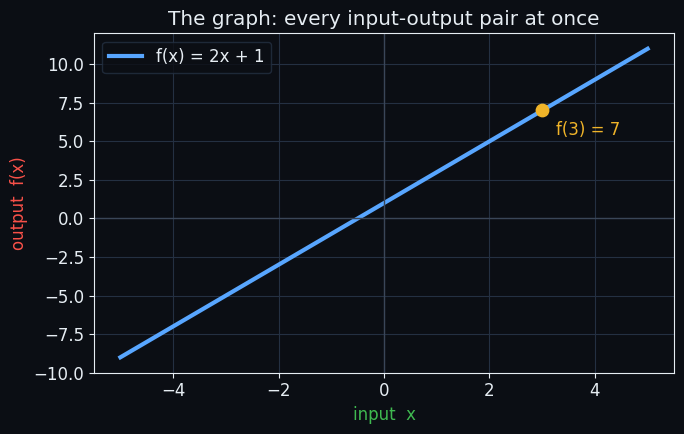

In [25]:
# =============================================================================
# SECTION 2 — The graph is the machine's portrait
# WHY: feed in MANY inputs at once (a NumPy array) and plot every output.
# =============================================================================
xs = np.linspace(-5, 5, 200)   # 200 inputs from -5 to 5
ys = f(xs)                      # NumPy applies the machine to all of them at once

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(xs, ys, color=BLUE, lw=3, label="f(x) = 2x + 1")
ax.scatter([3], [f(3)], color=YELLOW, zorder=5, s=80)            # one input/output pair
ax.annotate("f(3) = 7", (3, f(3)), textcoords="offset points",
            xytext=(10, -18), color=YELLOW, fontsize=12)
ax.axhline(0, color="#3a4658", lw=1); ax.axvline(0, color="#3a4658", lw=1)
ax.set_xlabel("input  x", color=GREEN); ax.set_ylabel("output  f(x)", color=RED)
ax.set_title("The graph: every input-output pair at once")
ax.legend(facecolor="#0b0e14", edgecolor="#243042")
fig.tight_layout(); fig.savefig("01_graph.png", dpi=120)
print("\nSECTION 2 — saved 01_graph.png")


SECTION 3 — saved 02_parameters.png


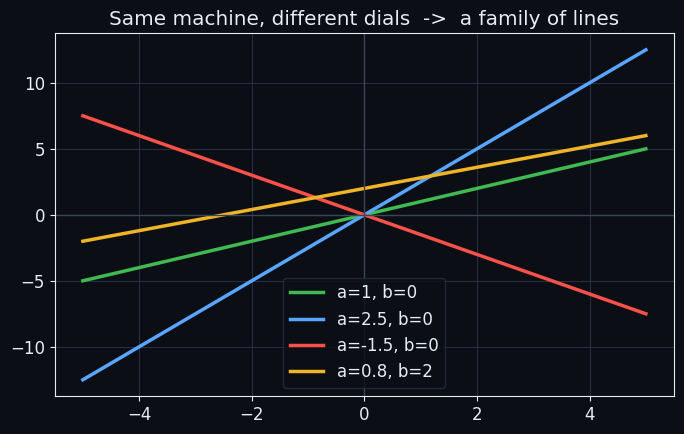

In [31]:
# =============================================================================
# SECTION 3 — Tuning the dials (parameters)
# WHY: this is the heart of ML. A function has knobs; changing them reshapes it.
# =============================================================================
def line(x, a, b):
    """A general straight-line machine with two dials: slope a, shift b."""
    return a * x + b

fig, ax = plt.subplots(figsize=(7, 4.5))
for a, b, c in [(1, 0, GREEN), (2.5, 0, BLUE), (-1.5, 0, RED), (0.8, 2, YELLOW)]:
    ax.plot(xs, line(xs, a, b), lw=2.5, color=c, label=f"a={a}, b={b}")
ax.axhline(0, color="#3a4658", lw=1); ax.axvline(0, color="#3a4658", lw=1)
ax.set_title("Same machine, different dials  ->  a family of lines")
ax.legend(facecolor="#0b0e14", edgecolor="#243042")
fig.tight_layout(); fig.savefig("02_parameters.png", dpi=120)
print("SECTION 3 — saved 02_parameters.png")

In [ ]:
# =============================================================================
# SECTION 4 — Three functions every ML person meets
# WHY: linear, quadratic, exponential reappear in models, losses, probabilities.
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
specs = [("Linear  f(x)=x",      lambda x: x,           GREEN),
         ("Quadratic  f(x)=x^2", lambda x: x**2,        YELLOW),
         ("Exponential  f(x)=e^x", lambda x: np.exp(x), PURPLE)]
for axi, (title, fn, c) in zip(axes, specs):
    axi.plot(xs, fn(xs), color=c, lw=3)
    axi.set_title(title, fontsize=11)
    axi.axhline(0, color="#3a4658", lw=1); axi.axvline(0, color="#3a4658", lw=1)
    axi.set_ylim(-5, 25)
fig.tight_layout(); fig.savefig("03_three_functions.png", dpi=120)
print("SECTION 4 — saved 03_three_functions.png")

In [ ]:
# =============================================================================
# SECTION 5 — Composition: machines feeding machines  f(g(x))
# WHY: stacking functions is exactly what a deep network does.
# =============================================================================
def g(x):   # add one
    return x + 1

def f2(x):  # double
    return 2 * x

# By hand, step by step, with the intermediate value printed (like the video).
x0 = 3
step1 = g(x0)          # 3 + 1 = 4
step2 = f2(step1)      # 2 * 4 = 8
print("\nSECTION 5 — composition")
print(f"  g(3)      = {step1}")
print(f"  f(g(3))   = {step2}")
# Same thing in one line:
compose = lambda x: f2(g(x))
print("  f(g(3)) via composition =", compose(3))

In [ ]:
# =============================================================================
# SECTION 6 — A TRAINABLE function: fit a line to data by turning the dials
# WHY: the punchline. "Training an AI = tuning a function's parameters."
#      We do it BY HAND (gradient descent on a and b), then check with sklearn.
# =============================================================================
# Make a small synthetic dataset: y ~ 2x + 1 plus noise.
X = np.linspace(-3, 3, 40)
true_a, true_b = 2.0, 1.0
Y = true_a * X + true_b + np.random.normal(0, 1.0, size=X.shape)

# --- BUILD FROM SCRATCH: gradient descent on mean squared error ---
def mse(a, b):
    pred = a * X + b
    return np.mean((pred - Y) ** 2)

a, b = 0.0, 0.0          # start with the dials at zero (a bad guess)
lr = 0.05                # learning rate (step size)
history = [(a, b, mse(a, b))]
for step in range(400):
    pred = a * X + b
    err = pred - Y
    # gradients of MSE w.r.t. each dial (the math, turned into code)
    grad_a = 2 * np.mean(err * X)
    grad_b = 2 * np.mean(err)
    a -= lr * grad_a     # turn the slope dial downhill
    b -= lr * grad_b     # turn the shift dial downhill
    history.append((a, b, mse(a, b)))

print("\nSECTION 6 — trained from scratch")
print(f"  learned a = {a:.3f}  (true {true_a})")
print(f"  learned b = {b:.3f}  (true {true_b})")
print(f"  final MSE = {mse(a, b):.3f}")

# --- VALIDATE against the library ---
from sklearn.linear_model import LinearRegression
reg = LinearRegression().fit(X.reshape(-1, 1), Y)
print(f"  sklearn a = {reg.coef_[0]:.3f},  b = {reg.intercept_:.3f}  (matches!)")

# Plot the fit + the learning curve
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4))
axL.scatter(X, Y, color=GREEN, s=30, label="data")
axL.plot(X, a * X + b, color=YELLOW, lw=3, label=f"learned: {a:.2f}x + {b:.2f}")
axL.set_title("The function learned to fit the data")
axL.legend(facecolor="#0b0e14", edgecolor="#243042")
losses = [h[2] for h in history]
axR.plot(losses, color=RED, lw=2)
axR.set_title("Loss going down as we tune the dials")
axR.set_xlabel("training step"); axR.set_ylabel("MSE")
fig.tight_layout(); fig.savefig("04_training.png", dpi=120)
print("SECTION 6 — saved 04_training.png")

In [ ]:
# =============================================================================
# SECTION 7 — BREAK IT ON PURPOSE: a learning rate that's too big
# WHY: the retention hook. The SAME code diverges if we mis-set one number,
#      then we fix it. Teaches that the dials must be turned gently.
# =============================================================================
def train(lr, steps=60):
    a, b = 0.0, 0.0
    losses = []
    for _ in range(steps):
        pred = a * X + b
        err = pred - Y
        a -= lr * 2 * np.mean(err * X)
        b -= lr * 2 * np.mean(err)
        losses.append(mse(a, b))
    return losses

bad = train(lr=0.6)     # too large -> the loss explodes
good = train(lr=0.05)   # gentle -> the loss settles

print("\nSECTION 7 — break it on purpose")
print(f"  too-big lr=0.6  -> final loss {bad[-1]:.1f}  (diverged!)" if np.isfinite(bad[-1])
      else "  too-big lr=0.6  -> loss became infinite (diverged!)")
print(f"  gentle  lr=0.05 -> final loss {good[-1]:.3f}  (converged)")

fig, ax = plt.subplots(figsize=(7, 4.5))
# Clip the exploding curve so the plot stays readable.
ax.plot(np.clip(bad, 0, 200), color=RED, lw=2.5, label="lr = 0.6 (too big: diverges)")
ax.plot(good, color=GREEN, lw=2.5, label="lr = 0.05 (gentle: converges)")
ax.set_title("Turn the dials too hard and learning breaks")
ax.set_xlabel("training step"); ax.set_ylabel("MSE (clipped at 200)")
ax.legend(facecolor="#0b0e14", edgecolor="#243042")
fig.tight_layout(); fig.savefig("05_break_it.png", dpi=120)
print("SECTION 7 — saved 05_break_it.png")

print("\nDone. A function is a machine — and training just turns its dials.")
# plt.show()  # uncomment when running interactively